In [19]:
import numpy as np
import pickle
import tensorflow as tf
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from keras.regularizers import l2
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

In [20]:
X_train = np.load('/kaggle/input/fake-news-detector/X_train.npy')
X_val = np.load('/kaggle/input/fake-news-detector/X_val.npy')
X_test = np.load('/kaggle/input/fake-news-detector/X_test.npy')

In [21]:
y_train = np.load('/kaggle/input/fake-news-detector/y_train.npy')
y_val = np.load('/kaggle/input/fake-news-detector/y_val.npy')
y_test = np.load('/kaggle/input/fake-news-detector/y_test.npy')

In [22]:
with open('/kaggle/input/fake-news-detector/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

In [23]:
max_len = 350
X_train = X_train[:, :max_len]
X_val = X_val[:, :max_len]
X_test = X_test[:, :max_len]

In [24]:
vocabulary_size = 10000
X_train = np.where(X_train > vocabulary_size, 0, X_train)
X_val = np.where(X_val   > vocabulary_size, 0, X_val)
X_test = np.where(X_test  > vocabulary_size, 0, X_test)

In [25]:
np.random.seed(42)
noise_factor = 0.10
noise = np.random.randint(0, vocabulary_size, size = X_train.shape)
noise_mask = np.random.random(X_train.shape) < noise_factor
X_train_noisy = np.where(noise_mask, noise, X_train)

In [26]:
dropout_mask = np.random.random(X_train_noisy.shape) > 0.1
X_train_noisy = np.where(dropout_mask, X_train_noisy, 0)

In [27]:
X_train_noisy = X_train_noisy.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

In [28]:
embedding_dim = 50
lstm_units = 32

In [29]:
model = Sequential([
    Embedding(
        input_dim = vocabulary_size + 1,
        output_dim = embedding_dim,
        input_length = max_len,
        mask_zero = True,
        embeddings_regularizer = l2(0.001),
        name = 'embedding'
    ),
    SpatialDropout1D(0.3),
    Bidirectional(
        LSTM(
            lstm_units,
            dropout = 0.6,
            recurrent_dropout = 0.6,
            kernel_regularizer = l2(0.001),
            name = 'lstm'
        )
    ),
    Dense(32, activation = 'relu', kernel_regularizer = l2(0.001), name = 'dense1'),
    Dropout(0.7),
    Dense(1, activation = 'sigmoid', dtype = 'float32', name = 'output')
])

In [30]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(
        learning_rate = 0.00015,
        clipnorm = 0.5
    ),
    metrics = ['accuracy']
)

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True,
    verbose = 1,
    min_delta = 0.0001
)

In [33]:
reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.6,
    patience = 1,
    min_lr = 0.00001,
    verbose = 1
)

In [34]:
class BatchHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs = None):
        self.batch_loss = []
        self.batch_accuracy = []
        self.epoch_val_loss = []
        self.epoch_val_accuracy = []

    def on_batch_end(self, batch, logs = None):
        self.batch_loss.append(logs.get('loss'))
        self.batch_accuracy.append(logs.get('accuracy'))

    def on_epoch_end(self, epoch, logs = None):
        self.epoch_val_loss.append(logs.get('val_loss'))
        self.epoch_val_accuracy.append(logs.get('val_accuracy'))

In [35]:
batch_history_callback = BatchHistory()

In [36]:
history = model.fit(
    X_train_noisy, y_train,
    validation_data = (X_val, y_val),
    epochs = 10,
    batch_size = 256,
    callbacks = [early_stop, reduce_lr, batch_history_callback],
    verbose = 1,
    shuffle = True
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.5215 - loss: 1.2197 - val_accuracy: 0.5470 - val_loss: 1.0359 - learning_rate: 1.5000e-04
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.5571 - loss: 0.9959 - val_accuracy: 0.5482 - val_loss: 0.8948 - learning_rate: 1.5000e-04
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.6021 - loss: 0.8690 - val_accuracy: 0.8753 - val_loss: 0.7642 - learning_rate: 1.5000e-04
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.8148 - loss: 0.7075 - val_accuracy: 0.9693 - val_loss: 0.4909 - learning_rate: 1.5000e-04
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8966 - loss: 0.5221 - val_accuracy: 0.9795 - val_loss: 0.2318 - learning_rate: 1.5000e-04
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9260 - loss: 0.3969 - val_accuracy: 0.9795 - val_loss: 0.1900 - learning_rate: 1.5000e-04
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - acc

In [37]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 1)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)')
print(f'Test Loss:     {test_loss:4f}')

182/182 ━━━━━━━━━━━━━━━━━━━━ 55s 305ms/step - accuracy: 0.9847 - loss: 0.1322
Test Accuracy: 0.9848 (98.48%)
Test Loss:     0.132155


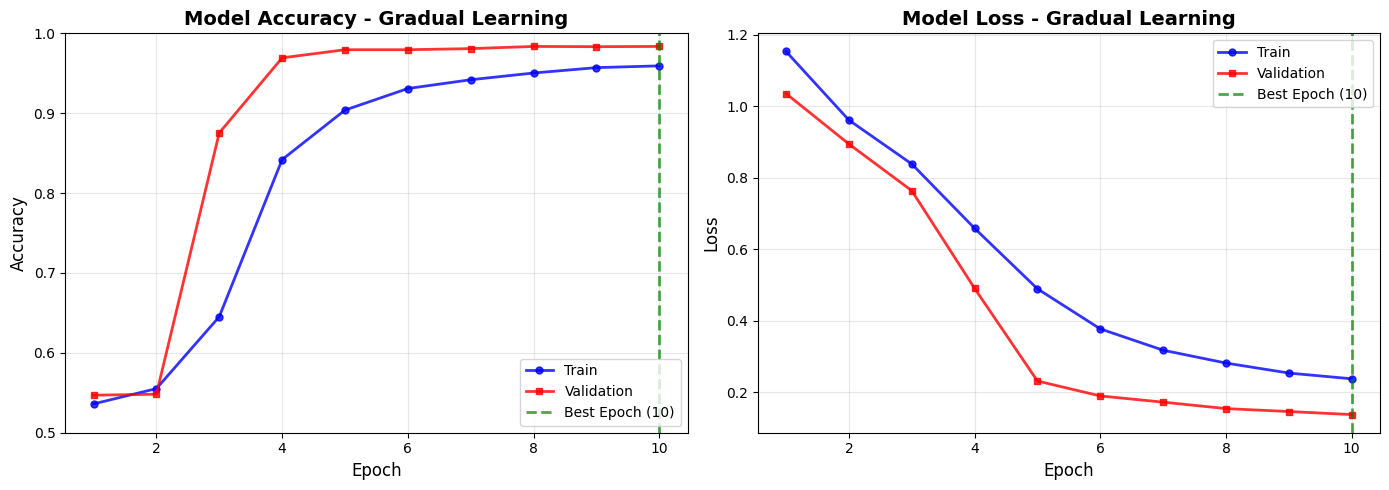

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)
best_epoch = np.argmin(history.history['val_loss']) + 1

ax1.plot(epochs_range, history.history['accuracy'],
        'b-o', label = 'Train', linewidth = 2, markersize = 5, alpha = 0.8)
ax1.plot(epochs_range, history.history['val_accuracy'],
        'r-s', label = 'Validation', linewidth = 2, markersize = 5, alpha = 0.8)
ax1.axvline(x = best_epoch, color = 'green', linestyle = '--',
           linewidth = 2, label = f'Best Epoch ({best_epoch})', alpha = 0.7)
ax1.set_title('Model Accuracy - Gradual Learning', fontsize = 14, fontweight = 'bold')
ax1.set_xlabel('Epoch', fontsize = 12)
ax1.set_ylabel('Accuracy', fontsize = 12)
ax1.legend(fontsize = 10, loc = 'lower right')
ax1.grid(True, alpha = 0.3)
ax1.set_ylim([0.5, 1.0])

ax2.plot(epochs_range, history.history['loss'],
        'b-o', label = 'Train', linewidth = 2, markersize = 5, alpha = 0.8)
ax2.plot(epochs_range, history.history['val_loss'],
        'r-s', label = 'Validation', linewidth = 2, markersize = 5, alpha = 0.8)
ax2.axvline(x = best_epoch, color = 'green', linestyle = '--',
           linewidth = 2, label = f'Best Epoch ({best_epoch})', alpha = 0.7)
ax2.set_title('Model Loss - Gradual Learning', fontsize = 14, fontweight = 'bold')
ax2.set_xlabel('Epoch', fontsize = 12)
ax2.set_ylabel('Loss', fontsize = 12)
ax2.legend(fontsize = 10, loc = 'upper right')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [39]:
batch_size = 256
num_samples = len(X_train_noisy)
num_batches_per_epoch = (num_samples // batch_size) + (1 if num_samples % batch_size else 0)

num_epochs_trained = len(batch_history_callback.epoch_val_accuracy)

val_steps_x = [(i + 1) * num_batches_per_epoch for i in range(num_epochs_trained)]

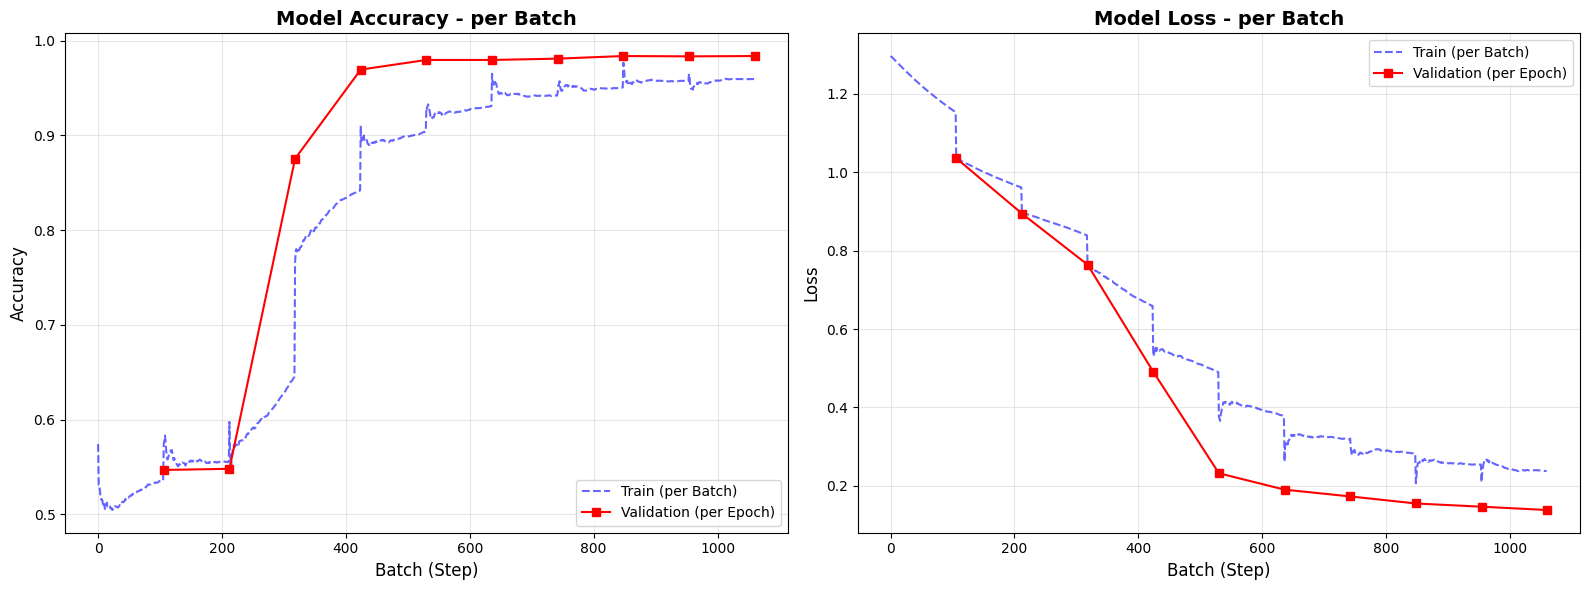

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

ax1.plot(batch_history_callback.batch_accuracy, 'b--', label = 'Train (per Batch)', alpha = 0.6)
ax1.plot(val_steps_x, batch_history_callback.epoch_val_accuracy, 'r-s', label = 'Validation (per Epoch)', markersize = 6)
ax1.set_title('Model Accuracy - per Batch', fontsize = 14, fontweight = 'bold')
ax1.set_xlabel('Batch (Step)', fontsize = 12)
ax1.set_ylabel('Accuracy', fontsize = 12)
ax1.legend(fontsize = 10, loc = 'lower right')
ax1.grid(True, alpha = 0.3)

ax2.plot(batch_history_callback.batch_loss, 'b--', label = 'Train (per Batch)', alpha = 0.6)
ax2.plot(val_steps_x, batch_history_callback.epoch_val_loss, 'r-s', label = 'Validation (per Epoch)', markersize = 6)
ax2.set_title('Model Loss - per Batch', fontsize = 14, fontweight = 'bold')
ax2.set_xlabel('Batch (Step)', fontsize = 12)
ax2.set_ylabel('Loss', fontsize = 12)
ax2.legend(fontsize = 10, loc = 'upper right')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

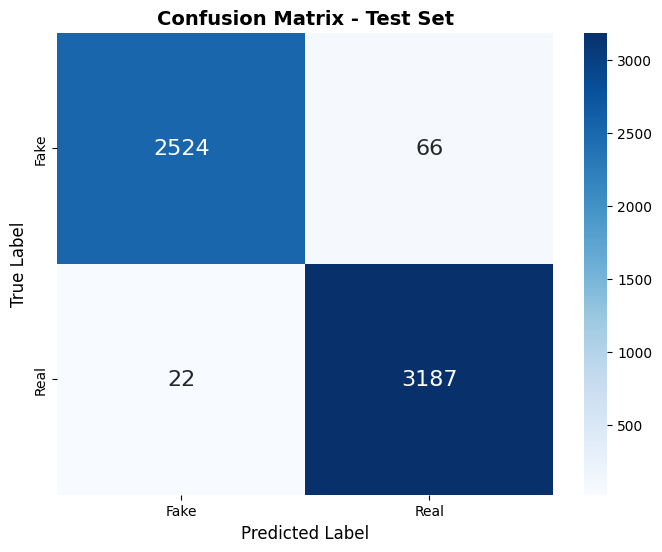

In [43]:
y_pred_probs = model.predict(X_test, verbose = 0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = True,
           xticklabels = ['Fake', 'Real'],
           yticklabels = ['Fake', 'Real'],
           annot_kws = {'size': 16})
plt.title('Confusion Matrix - Test Set', fontsize = 14, fontweight = 'bold')
plt.ylabel('True Label', fontsize = 12)
plt.xlabel('Predicted Label', fontsize = 12)
plt.show()